# Exploração dos dados de REEE (SINIR 2019–2025)

Notebook de apoio ao objetivo II: inspeciona os arquivos brutos, mostra as regras de limpeza aplicadas pelo pipeline e explora os indicadores gerados.

> Rode antes `PYTHONPATH=src python -m reee.pipeline --demo` (ou sem `--demo` com dados reais).

In [1]:
import sys, json
sys.path.insert(0, '../src')
import pandas as pd
from reee import config as C, extract
from reee.utils import numero_br, normalizar_texto
pd.set_option('display.max_columns', 30)

## 1. Arquivos brutos
Layouts diferentes por ano: encoding, separador e nomes de coluna.

In [2]:
fonte = C.RAW_SINIR if any(C.RAW_SINIR.glob('*ponto*')) else C.RAW_DEMO
brutos = extract.extrair(fonte)
for df in brutos['pontos'][:1] + brutos['pontos'][-1:]:
    print(df['_arquivo'].iloc[0], list(df.columns))
brutos['pontos'][0].head()

sinir_pontos_recebimento_2019.csv ['id_ponto', 'UF', 'Município', 'Código IBGE', 'Entidade Gestora', 'Tipo de Ponto', 'Situação', 'Data de Cadastro', '_arquivo', '_ano_arquivo']
sinir_pontos_recebimento_2025.csv ['id_ponto', 'ano', 'sigla_uf', 'nome_municipio', 'geocodigo', 'sistema', 'modalidade', 'status', 'inicio_operacao', '_arquivo', '_ano_arquivo']


,id_ponto,UF,Município,Código IBGE,Entidade Gestora,Tipo de Ponto,Situação,Data de Cadastro,_arquivo,_ano_arquivo
0,2111300-029,MA,SÃO LUÍS,2111300,ABREE,PEV fixo,Ativo,17/10/2019,sinir_pontos_recebimento_2019.csv,2019
1,4301925-000,RS,Barra do Rio Azul,4301925,ABREE,PEV fixo,Ativo,09/06/2019,sinir_pontos_recebimento_2019.csv,2019
2,3532900-005,SP,Nova Europa,3532900,ABREE,Campanha itinerante,Ativo,15/04/2019,sinir_pontos_recebimento_2019.csv,2019
3,3301702-000,RJ,Duque de Caxias,3301702,ABREE,PEV fixo,Ativo,17/10/2019,sinir_pontos_recebimento_2019.csv,2019
4,5300108-024,DF,Brasília,5300108,Green Eletron,PEV fixo,Ativo,19/09/2019,sinir_pontos_recebimento_2019.csv,2019


## 2. Problemas típicos

In [3]:
pts = pd.concat(brutos['pontos'], ignore_index=True)
col_mun = [c for c in pts.columns if 'unic' in c.lower()]
print('Grafias diferentes do mesmo município (exemplo):')
nomes = pd.concat([pts[c] for c in col_mun]).dropna()
nomes[nomes.map(normalizar_texto) == 'sao paulo'].value_counts()

Grafias diferentes do mesmo município (exemplo):


São Paulo       993
SÃO PAULO       493
Sao Paulo       298
  São Paulo     163
Name: count, dtype: int64

In [4]:
print([numero_br(x) for x in ['1.234,56', '12,5 t', '-', '1234.5']])

[1234.56, 12.5, nan, 1234.5]


## 3. Relatório de qualidade do pipeline

In [5]:
json.loads((C.PROCESSED / 'qualidade.json').read_text(encoding='utf-8'))

{'fonte': 'demo',
 'pontos_linhas_lidas': 30440,
 'pontos_fora_do_periodo': 0,
 'pontos_inativos_removidos': 618,
 'pontos_codigo_recuperado_por_nome': 458,
 'pontos_sem_municipio_descartados': 0,
 'pontos_duplicados_removidos': 300,
 'pontos_registros_validos': 29522,
 'massa_linhas_lidas': 12401,
 'massa_valores_invalidos': 0,
 'massa_codigo_recuperado_por_nome': 0,
 'massa_sem_municipio_descartados': 0,
 'massa_outliers_sinalizados': 41}

## 4. Indicadores

In [6]:
br = pd.read_csv(C.PROCESSED / 'indicadores_brasil_ano.csv')
br[['ano','pontos','toneladas','obrigados_com_ponto','meta_municipios','pct_pop_coberta','deficit_pontos']]

,ano,pontos,toneladas,obrigados_com_ponto,meta_municipios,pct_pop_coberta,deficit_pontos
0,2019,984,337.572018,64,NaN,25.26,4293
1,2020,2168,863.479285,141,NaN,49.28,3539
2,2021,3285,1477.154000,210,24.0,57.70,2836
3,2022,4502,2659.051000,278,72.0,65.03,2109
4,2023,5548,3374.451000,340,130.0,71.09,1534
5,2024,6285,4555.183000,379,240.0,75.63,1262
6,2025,6750,5845.125000,397,400.0,78.50,1120


In [7]:
uf = pd.read_csv(C.PROCESSED / 'indicadores_uf_ano.csv')
uf[uf.ano == uf.ano.max()].sort_values('pontos_100k', ascending=False)[['uf','pontos','pontos_100k','pct_pop_coberta','kg_hab']].head(10)

,uf,pontos,pontos_100k,pct_pop_coberta,kg_hab
188,TO,91,6.017,61.18,0.0463
118,PI,162,4.952,69.83,0.0337
160,RS,491,4.511,73.67,0.0334
76,MG,899,4.377,78.10,0.0330
104,PB,152,3.824,64.77,0.0295
139,RN,124,3.754,68.74,0.0280
167,SC,285,3.744,70.33,0.0324
69,MA,250,3.689,73.59,0.0423
48,DF,103,3.656,100.00,0.1347
132,RJ,550,3.426,94.64,0.0371


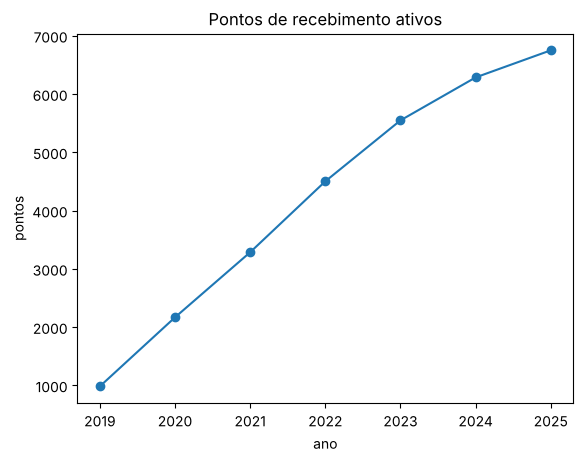

In [8]:
ax = br.plot(x='ano', y='pontos', marker='o', title='Pontos de recebimento ativos', legend=False)
ax.set_ylabel('pontos');

## 5. Prioridade

In [9]:
prio = pd.read_csv(C.PROCESSED / 'prioridade_novos_pontos.csv')
prio[['municipio','uf','populacao','pontos','deficit_pontos','indice_prioridade','classe_prioridade']].head(15)

,municipio,uf,populacao,pontos,deficit_pontos,indice_prioridade,classe_prioridade
0,Goiânia,GO,1615206,24,41,84.3,Alta
1,Curitiba,PR,3437778,93,45,84.1,Alta
2,Belém,PA,2241403,36,54,82.0,Alta
3,Campo Grande,MS,892300,14,22,74.6,Alta
4,Manaus,AM,781205,13,19,73.3,Alta
5,João Pessoa,PB,848772,16,18,73.1,Alta
6,Cuiabá,MT,720637,11,18,72.4,Alta
7,Ribeirão Branco,SP,441262,7,11,64.3,Alta
8,Salvador,BA,4036833,141,21,63.3,Alta
9,Senador José Porfírio,PA,102047,0,5,62.9,Alta
